In [1]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanBase
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 1073.741824


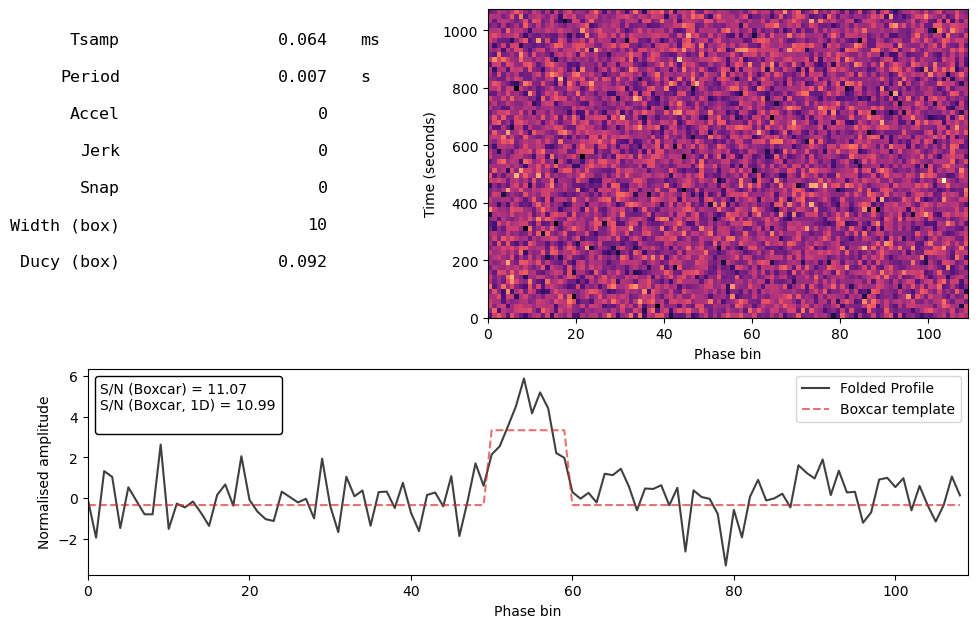

In [2]:
pulsar_period = 0.007
dt = 64e-6
nsamps = 2**24
mod_kwargs = {"p_orb": 1200, "psi": np.pi / 4.1, "m_c": 8}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=11,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
    mod_type="circular",
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs, mod_type="circular")
plt.show()

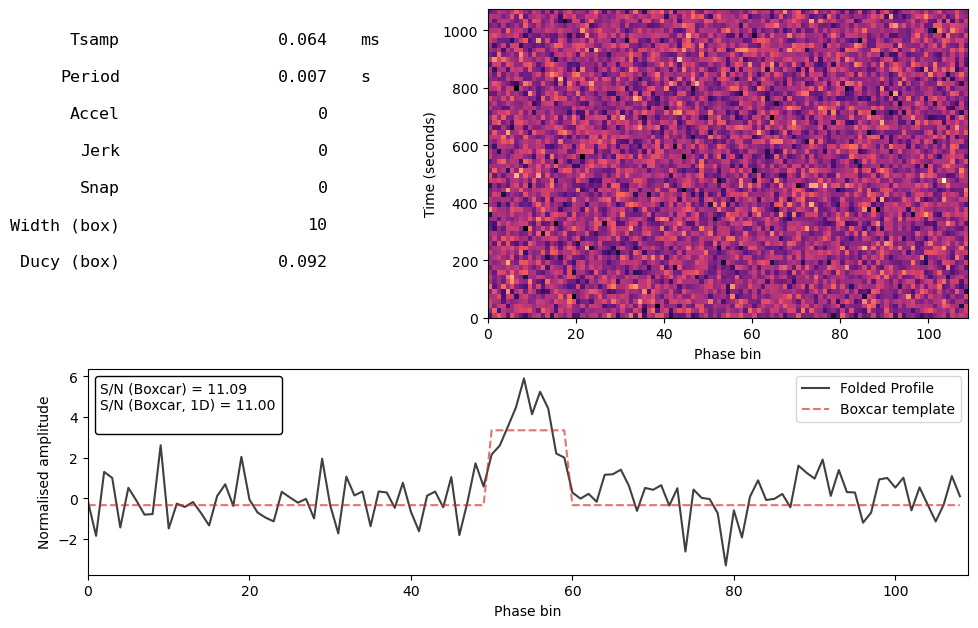

In [3]:
tim_data.plot_fold(
    cfg.freq,
    cfg.fold_bins,
    mod_kwargs=cfg.mod_func.to_derivatives_series(n=15),
    mod_type="derivative_series",
)
plt.show()

In [4]:
eta = 1
nbins = 64
p_orb_min = cfg.tobs
m_p_min=1.2
m_c_max=10
p = ParamLimits.from_circular((142.5, 143.5), p_orb_min, m_c_max, m_p=m_p_min, poly_order=5)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=5,
    nthreads=4,
    ducy_max=0.5,
    wtsp=1.2,
    use_fourier=True,
    m_p_min=m_p_min,
    m_c_max=m_c_max,
    p_orb_min=p_orb_min,
)
plan = FFAPlanBase(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-2.15432852e-03  2.15432852e-03]
 [-3.68156042e-01  3.68156042e-01]
 [-6.29146716e+01  6.29146716e+01]
 [-1.07515712e+04  1.07515712e+04]
 [ 1.41626654e+02  1.44379474e+02]]


array([4.        , 9.        , 1.        , 2.25575101, 3.98980204,
       3.        , 2.80514208, 3.20839363, 1.        , 1.        ,
       3.        , 1.        , 1.        , 2.25575101, 1.99490102,
       3.        , 1.        , 3.        , 1.        , 3.        ,
       1.        , 1.        , 2.80514208, 1.06946454, 2.41001353,
       3.73441887, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 8.13125846, 1.10683974,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 2.25575101, 2.85602879,
       1.39697543, 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       2.80514208, 1.06946454, 1.        , 1.        , 1.     

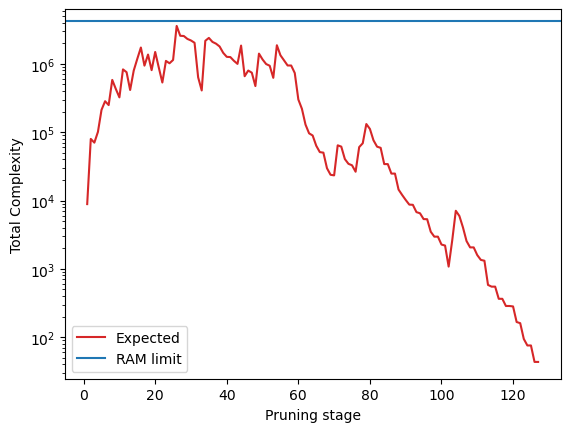

In [7]:
thresholds = np.array([1.1, 1.7, 2.2, 2.6, 2.9, 3.2, 3.6, 3.5, 3.5, 3.5, 3.4, 3.3, 3.7,
       3.6, 3.7, 4. , 4.2, 4.4, 4.5, 4.6, 4.7, 4.8, 4.8, 4.7, 5. , 4.9,
       5. , 4.6, 4.7, 4.6, 4.6, 5.2, 5.3, 5.4, 5. , 5.2, 5.1, 5.1, 5.2,
       5.2, 4.9, 5.1, 5.1, 5.2, 5.9, 5.8, 5.7, 5.9, 5.6, 5.8, 5.8, 5.7,
       5.9, 5.4, 5.9, 5.9, 5.9, 5.6, 5.9, 6.5, 6.5, 6.6, 6.6, 6.5, 6.6,
       6.6, 6.4, 6.7, 6.7, 6.5, 6.4, 6.5, 6.7, 6.7, 6.6, 6.7, 6.6, 6.6,
       6.8, 6.8, 6.9, 6.9, 6.8, 7. , 6.7, 7. , 6.4, 7.1, 7.1, 7.1, 7.1,
       6.9, 7.1, 7. , 7.1, 6.9, 7.2, 7.2, 6.6, 7.2, 7.1, 7.4, 7.4, 6.8,
       7.4, 7.5, 7.6, 7.6, 6.9, 7.6, 7.6, 7.5, 7.8, 7.7, 7.1, 7.8, 7.6,
       7.8, 7.1, 7.6, 7.9, 7.8, 8. , 8. , 7.6, 8.1, 7.4])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=11,
    ducy_max=0.5,
    wtsp=1.2,
)
x = np.arange(1, len(branching_pattern) + 1)
nparam_vol = plan.ncoords[-1]
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [8]:
ep_manager = EPMultiPassFourier(
    search_cfg,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    batch_size=1024,
    poly_basis="taylor",
    show_progress=False,
)
ep_manager.execute(
    tim_data.ts_e,
    tim_data.ts_v,
    outdir="pruning_results/circular_test/",
    file_prefix="test_circular",
)

[2026-04-25 15:23:06.734] [info] EPMultiPass: Initializing with FFA
[2026-04-25 15:23:06.749] [info] P-FFA [8192, 1, 1, 1, 1, 12, 2, 33] -> [128, 1, 1, 1, 3, 739, 2, 33]
[2026-04-25 15:23:06.749] [info] FFA Memory Usage: 0.28 GB + 0.00 GB (coords)
[2026-04-25 15:23:07.381] [info] Starting Pruning for 16 runs, with 4 threads
[2026-04-25 15:23:07.384] [info] Pruning run 028: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-25 15:23:07.384] [info] Pruning run 004: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-25 15:23:07.384] [info] Pruning run 012: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-25 15:23:07.384] [info] Pruning run 028: initialized
[2026-04-25 15:23:07.384] [info] Pruning run 020: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-25 15:23:07.384] [info] Pruning run 020: initialized
[2026-04-25 15:23:07.384] [info] Pruning run 004: initialized
[2026-04-25 15:23:07.384] [info] Pruning run 012: initialized
[2026-04-25 15:23:29.4

In [9]:
result_file = "pruning_results/circular_test/test_circular_pruning_nstages_128_results.h5"
pgram = ScatteredPeriodogram.load(result_file)
param_true = cfg.mod_func.to_derivatives_gauge(cfg.freq)
crac_true = param_true["crackle"]
snap_true = param_true["snap"]
jerk_true = param_true["jerk"]
acc_true = param_true["acc"]
freq_true = param_true["freq"]
print(
    f"True params, c: {crac_true:.3f}, s: {snap_true:.3f}, j: {jerk_true:.3f}, "
    f"a: {acc_true:.3f}, f: {freq_true:.10f}",
)
print(pgram.get_summary_cands(10, score_type="score", run_id=None))

True params, c: 0.001, s: 0.159, j: -31.566, a: -5802.064, f: 142.3105761558
Top candidates:
dparams: dcrackle: 1.966095547e-06, dsnap: 0.0001119962407, djerk: 0.006379727438, daccel: 0.8176826732, dfreq: 4.598840254e-05
Run: 052_07, S/N (EP): 9.39, S/N: 10.92, crackle: 0.0008652, snap: 0.15907, jerk: -31.5605, accel: -5802.25, freq: 142.310642
Run: 052_07, S/N (EP): 9.18, S/N: 10.50, crackle: 0.0008660, snap: 0.15931, jerk: -31.5610, accel: -5805.72, freq: 142.310692
Run: 052_07, S/N (EP): 8.30, S/N: 10.39, crackle: 0.0008652, snap: 0.15907, jerk: -31.5606, accel: -5802.25, freq: 142.310596
Run: 052_07, S/N (EP): 9.25, S/N: 10.28, crackle: 0.0008663, snap: 0.15934, jerk: -31.5599, accel: -5804.87, freq: 142.310704
Run: 052_07, S/N (EP): 9.24, S/N: 10.28, crackle: 0.0008661, snap: 0.15932, jerk: -31.5543, accel: -5804.28, freq: 142.310690
Run: 052_07, S/N (EP): 9.48, S/N: 10.26, crackle: 0.0008664, snap: 0.15936, jerk: -31.5520, accel: -5803.38, freq: 142.310696
Run: 052_07, S/N (EP): 

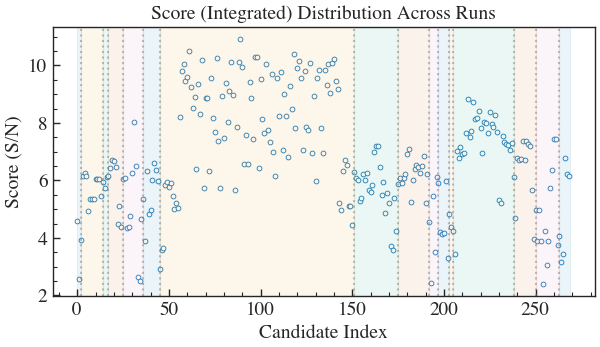

In [10]:
pgram.plot_scores(kind="scatter", run_id=None); plt.show()

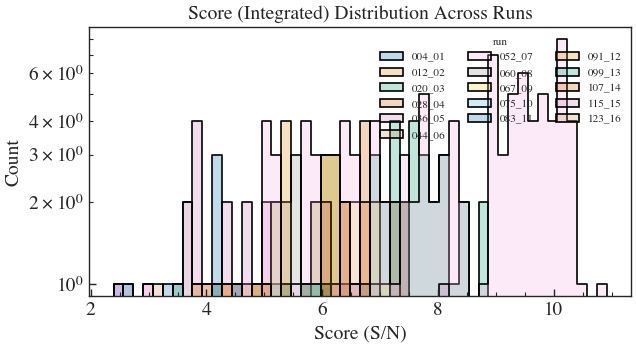

In [11]:
pgram.plot_scores(kind="hist", run_id=None); plt.show()

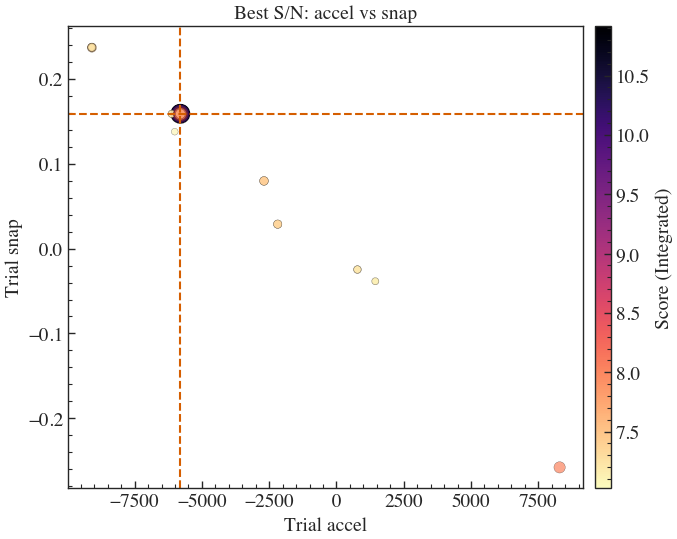

In [13]:
pgram.plot_correlation("accel", "snap", true_values={"snap": snap_true, "accel": acc_true}, run_id=None, snr_min=7); plt.show()

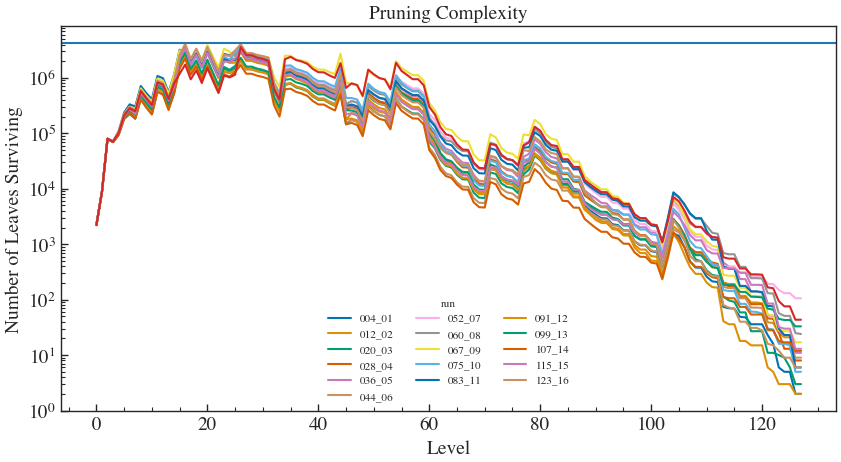

In [14]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()